In [17]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_auc_score

In [11]:
df = pd.read_csv('cleaned_churn_data.csv')

In [ ]:
y = df['Churn']
X = df.drop('Churn', axis=1)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = ['Contract','InternetService','PaymentMethod']
# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ],
    remainder='passthrough'
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model.fit(X_train, y_train)


Understanding Analysis \

A logistic regression model outputs a probability, we convert probability to a class using a threshold. \

Confusion Matrix is the foundation of the classification metrics, where: \
TP - True Positive (customer churns, model predicted churn)\
TN - True Negative (customer stays, model predicted stay) \
FP - False Positive (customer stays, model predicted churn) \
FN - False Negative (customer churns, model predicted stay) \

Accuracy - measures overall correctness \
Precision - how often is the model correct in it's predictions TP / (TP + FP) \
Recall - of all customers who churned, how many did the model detect \
ROC-AUC - how well the model separates the two classes \


In [15]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
#Accuracy is 79%. For this dataset, since churn is 26%, even if the model predicts every one stays the accuracy is 75%. So accuracy can be misleading.
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7924662402274343


In [ ]:
#Precision is 63%. This indicates that the model is correct 63% of the time.
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.6348684210526315


In [ ]:
#model predicted 52% of the customers who churned 
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.516042780748663


In [21]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[922 111]
 [181 193]]


In [22]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8314666797811265


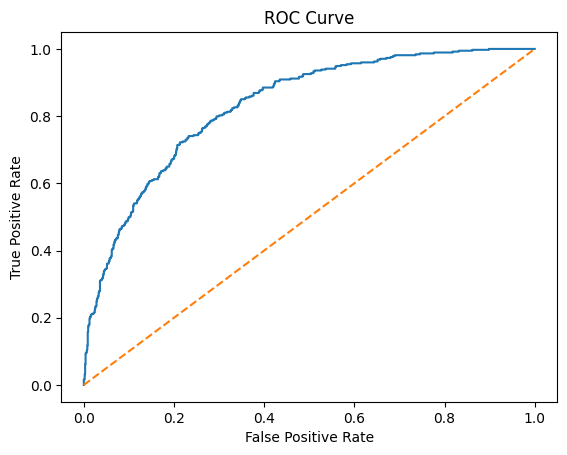

In [23]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [26]:
coefficients = model.named_steps['classifier'].coef_[0]
features = model.named_steps['preprocessor'].get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

print(coef_df)

                                       Feature  Coefficient
5             cat__InternetService_Fiber optic     0.878405
2                            num__TotalCharges     0.661098
8          cat__PaymentMethod_Electronic check     0.329956
22                 remainder__PaperlessBilling     0.311753
11                    remainder__SeniorCitizen     0.297697
15                    remainder__MultipleLines     0.241337
1                          num__MonthlyCharges     0.108123
12                          remainder__Partner     0.049183
19                      remainder__TechSupport     0.000000
21                  remainder__StreamingMovies     0.000000
18                 remainder__DeviceProtection     0.000000
20                      remainder__StreamingTV     0.000000
17                     remainder__OnlineBackup     0.000000
16                   remainder__OnlineSecurity     0.000000
10                           remainder__gender    -0.018274
9              cat__PaymentMethod_Mailed